# DOT PY — Data Science & AI Program
## Module 02 · Machine Learning
### In-Class Task Session — Regression (Student Template)

---

**Instructor:** Mohamed Walid  
**Cohort:** DSA-2026  
**Dataset:** Titanic Clean (output from Module 01)  
**Objective:** Build, compare, and evaluate regression models using a preprocessed real-world dataset

---

> **How to use this notebook:**  
> Read the markdown explanation for each section *before* writing your code.  
> Each code cell contains a `TODO` comment with hints — write the code yourself.  
> Do not just copy a solution — understand *why* each step is needed before you write it.


---

## Business Brief — Why Are We Learning Regression?

### The Problem

In Module 01 we cleaned the Titanic dataset.  
Now the question changes — instead of asking *"who survived?"*, we ask:

> **Can we predict the fare a passenger paid based on their profile?**

This is a **regression problem** — our target variable `Fare` is a continuous number, not a category.

Regression is one of the most widely used techniques in real business:

| Business Problem | Regression Target |
|-----------------|------------------|
| Predict house price | Price in EGP or USD |
| Forecast monthly revenue | Revenue amount |
| Estimate loan repayment amount | Payment in currency |
| Predict customer lifetime value | Total spend over time |
| Estimate delivery time | Minutes or days |

---

### What We Are Building in This Session

We will build **five models** in order of increasing complexity:

| Model | What It Assumes |
|-------|----------------|
| **Linear Regression** | The relationship between features and target is a straight line |
| **Polynomial Regression** | The relationship is a curve — we add non-linear terms |
| **Ridge Regression** | Linear + L2 regularization — penalizes large coefficients |
| **Lasso Regression** | Linear + L1 regularization — shrinks some coefficients to exactly zero |
| **ElasticNet** | Combines both L1 and L2 — a balance between Ridge and Lasso |

---

### What Are We Evaluating?

After building each model, we measure its performance using three metrics:

| Metric | Formula | What It Tells You |
|--------|---------|------------------|
| **MAE** | mean(|actual - predicted|) | Average error in the same unit as the target |
| **MSE** | mean((actual - predicted)²) | Penalizes large errors more heavily — sensitive to outliers |
| **R²** | 1 - (SS_res / SS_tot) | How much variance in the target does the model explain — higher is better |

> **Rule of thumb:**  
> R² close to 1 → model explains the data well  
> R² close to 0 → model is barely better than just predicting the mean  
> R² negative → model is worse than predicting the mean — something is wrong

---

### What We Are NOT Doing

We are using the full clean dataset for demonstration — no train/test split here yet.  
Train/test split and cross-validation are covered in the next session.

---


---
## 1. Import Libraries

| Library | Why we need it |
|---------|---------------|
| `pandas`, `numpy` | Data handling |
| `matplotlib`, `seaborn` | Visualization |
| `sklearn.linear_model` | All five regression models |
| `sklearn.metrics` | MAE, MSE, R² evaluation |
| `sklearn.preprocessing` | PolynomialFeatures |
| `sklearn.model_selection` | train_test_split |


In [ ]:
# TODO: Import everything needed for this notebook
# Hint: from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# Hint: from sklearn.preprocessing import PolynomialFeatures
# Hint: from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Hint: from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

---
## 2. Load the Clean Dataset

We load the preprocessed Titanic dataset from Module 01.  
This dataset is already cleaned, encoded, and scaled — no preprocessing needed.


In [ ]:
# TODO: Load 'titanic_clean.csv' into a DataFrame called df
# Then print the shape and show df.head()
# Hint: pd.read_csv()
df = pd.read_csv('/content/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,1,22,1,0,7,0,1,2,0
1,1,1,0,38,1,0,65,0,0,2,0
2,1,3,0,26,0,0,7,0,1,1,1
3,1,1,0,35,1,0,53,0,1,2,0
4,0,3,1,35,0,0,8,0,1,1,1


---
## 3. Define Features and Target

**Target variable:** `Fare` — the continuous value we want to predict

**Features:** all other columns except `Fare` and `Survived`  
(We drop `Survived` because it is not available at the time of boarding — a passenger's fare was set before the disaster)

> This step is called **feature-target separation**.  
> X contains the inputs the model learns from.  
> y contains the answers the model tries to predict.


In [ ]:
# TODO: Create X (features) and y (target)
# Drop 'Fare' and 'Survived' from the features
# y should be the 'Fare' column
# Print the shapes of X and y to confirm
x = df.drop(['Fare', 'Survived'], axis=1)
y = df['Fare']
x.shape, y.shape


((891, 9), (891,))

---
## 4. Train / Test Split

We split the dataset into two parts:

| Part | Size | Purpose |
|------|------|---------|
| **Train set** | 80% | The model learns from this data |
| **Test set** | 20% | We evaluate the model on data it has never seen |

> **Why do we need a test set?**  
> If we train and evaluate on the same data, the model might just memorize the answers  
> instead of learning a general pattern. This is called **overfitting**.  
> The test set simulates real-world performance on unseen data.

We use `random_state=42` to make the split reproducible — everyone in the session gets the same split.


In [ ]:
# TODO: Split X and y into X_train, X_test, y_train, y_test
# Use test_size=0.2 and random_state=42
# Print the shapes of all four to confirm
# Hint: train_test_split()

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'x_train = {x_train.shape}, x_test = {x_test.shape}, y_train = {y_train.shape}, y_test = {y_test.shape}')

x_train = (712, 9), x_test = (179, 9), y_train = (712,), y_test = (179,)


---
## 5. Evaluation Helper

We will use this helper function throughout the notebook to evaluate every model consistently.  
It calculates MAE, MSE, and R² and stores the results so we can compare all models at the end.

**What each metric tells you:**

**MAE (Mean Absolute Error)**  
The average size of the error, ignoring direction.  
Easy to interpret — if MAE = 5, your predictions are off by 5 fare units on average.

**MSE (Mean Squared Error)**  
Same idea as MAE but squares the errors first.  
This means large errors are punished much more heavily.  
Useful when big mistakes are particularly costly.

**R² (R-squared / Coefficient of Determination)**  
Measures what percentage of the variance in Fare the model explains.  
R² = 1 → perfect model, R² = 0 → model learns nothing useful.


In [ ]:
# TODO: Create an empty dictionary called results = {} to store model scores
# Then write a function called evaluate(name, y_test, y_pred) that:
# 1) Calculates MAE, MSE, and R² using sklearn.metrics
# 2) Stores the three values in results[name] = {'MAE': ..., 'MSE': ..., 'R2': ...}
# 3) Prints the three values in a readable format
# Hint: mean_absolute_error, mean_squared_error, r2_score

results= {}

def evaluate(name, y_test, y_pred):
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
  print(f'{name}: MAE = {mae:.4f}, MSE = {mse:.4f}, R2 = {r2:.4f}')
  return results



---
## 6. Linear Regression

**What it does:**  
Finds the best-fit straight line through the data by minimizing the sum of squared errors.

**The formula:**  
`ŷ = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ`

Where:
- `ŷ` is the predicted value
- `β₀` is the intercept (baseline value when all features are 0)
- `β₁, β₂, ...` are the coefficients — how much each feature contributes to the prediction

**When to use it:**  
When you believe the relationship between features and target is approximately linear.  
It is always the first model to try — it is fast, interpretable, and sets a performance baseline.

**Limitation:**  
Cannot capture curved or non-linear relationships in the data.


In [ ]:
# TODO: Build a Linear Regression model
# 1) Create a LinearRegression() instance
# 2) Fit it on X_train, y_train
# 3) Predict on X_test
# 4) Call evaluate('Linear Regression', y_test, y_pred)

linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)
y_pred = linear_reg.predict(x_test)
results.update(evaluate("LinearRegression", y_test, y_pred))

LinearRegression: MAE = 7.7898, MSE = 119.9905, R2 = 0.7090


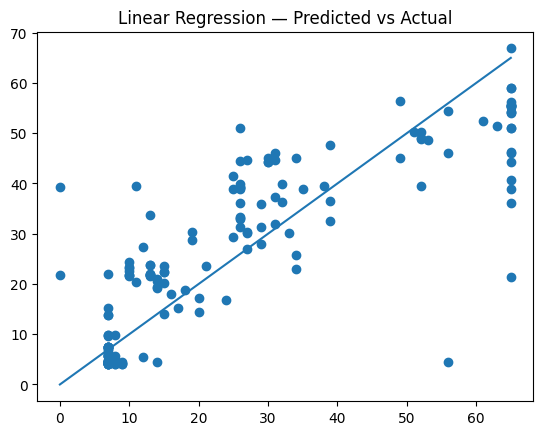

In [ ]:
# TODO: Visualize the predictions vs actual values
# Create a scatter plot with y_test on x-axis and y_pred on y-axis
# Add a diagonal reference line (perfect prediction line) using plt.plot([min, max], [min, max])
# Title: 'Linear Regression — Predicted vs Actual'
# Hint: this line shows how close predictions are to reality

plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.title('Linear Regression — Predicted vs Actual')
plt.show()

---
## 7. Polynomial Regression

**What it does:**  
Extends Linear Regression by adding polynomial (curved) terms.  
Instead of fitting a straight line, it fits a curve.

**How it works:**  
We use `PolynomialFeatures` to transform the original features.  
For degree=2, each feature `x` becomes `[1, x, x²]` — and all interaction terms are added too.  
Then we feed these transformed features into a regular `LinearRegression` model.

**Example:**  
If we have features Age and Pclass:  
After degree=2 transformation → Age, Pclass, Age², Pclass², Age×Pclass, 1  
The model now has many more signals to learn from.

**When to use it:**  
When you suspect a non-linear relationship between features and target — but the pattern is still smooth.

**Warning:**  
High degrees (3, 4, 5+) can cause **overfitting** — the model memorizes the training data  
instead of learning a general pattern. Start with degree=2.


In [ ]:
# TODO: Build a Polynomial Regression model (degree=2)
# 1) Create PolynomialFeatures(degree=2, include_bias=False)
# 2) Transform BOTH X_train and X_test using fit_transform on train, transform on test
# 3) Fit a LinearRegression model on the polynomial features
# 4) Predict on X_test polynomial features
# 5) Call evaluate('Polynomial Regression (deg=2)', y_test, y_pred)
# Hint: do NOT fit PolynomialFeatures on the test set — only transform it

poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)
linear_reg_poly = LinearRegression()
linear_reg_poly.fit(x_train_poly, y_train)
y_pred_poly = linear_reg_poly.predict(x_test_poly)

results.update(evaluate("Polynomial Regression (deg=2)", y_test, y_pred_poly))



Polynomial Regression (deg=2): MAE = 5.7383, MSE = 103.2078, R2 = 0.7497


---
## 8. Ridge Regression (L2 Regularization)

**What it does:**  
Same as Linear Regression, but adds a penalty on the size of the coefficients.

**The formula:**  
`Loss = MSE + α × Σ(βᵢ²)`

The model is forced to keep coefficients small.  
This prevents any single feature from dominating the prediction too aggressively.

**What is α (alpha)?**  
The regularization strength — how hard we penalize large coefficients.  
- α = 0 → same as Linear Regression, no penalty
- α = very large → all coefficients shrink toward zero

**What Ridge does NOT do:**  
Ridge shrinks coefficients but almost never sets them to exactly zero.  
All features stay in the model.

**When to use it:**  
When you have many correlated features (multicollinearity) and want to stabilize the model  
without removing features entirely.


In [ ]:
# TODO: Build a Ridge Regression model
# 1) Create Ridge(alpha=1.0)
# 2) Fit on X_train, y_train
# 3) Predict on X_test
# 4) Call evaluate('Ridge (alpha=1.0)', y_test, y_pred)

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(x_train, y_train)
y_pred_ridge = ridge_reg.predict(x_test)

results.update(evaluate("Ridge (alpha=1.0)", y_test, y_pred_ridge))



Ridge (alpha=1.0): MAE = 7.7839, MSE = 119.9270, R2 = 0.7091


In [ ]:
# TODO: Experiment — try three different alpha values: 0.1, 1.0, 10.0
# For each alpha, fit Ridge, predict, and print the R² score
# What do you notice as alpha increases?
# Hint: a for loop over alphas = [0.1, 1.0, 10.0]

li = [0.1 , 1.0 , 10.0]

for alpha in li:
  ridge_reg = Ridge(alpha=alpha)
  ridge_reg.fit(x_train, y_train)
  y_pred_ridge = ridge_reg.predict(x_test)
  results.update(evaluate(f"LinearRegRidge (alpha={alpha}ression", y_test, y_pred_ridge))





LinearRegRidge (alpha=0.1ression: MAE = 7.7892, MSE = 119.9839, R2 = 0.7090
LinearRegRidge (alpha=1.0ression: MAE = 7.7839, MSE = 119.9270, R2 = 0.7091
LinearRegRidge (alpha=10.0ression: MAE = 7.7371, MSE = 119.5932, R2 = 0.7099


---
## 9. Lasso Regression (L1 Regularization)

**What it does:**  
Same penalty idea as Ridge, but uses the absolute value instead of squaring.

**The formula:**  
`Loss = MSE + α × Σ|βᵢ|`

**The key difference from Ridge:**  
Lasso can shrink coefficients all the way to **exactly zero**.  
This means Lasso performs automatic **feature selection** — it removes features that do not contribute.

| | Ridge | Lasso |
|-|-------|-------|
| Penalty type | L2 (squared) | L1 (absolute) |
| Coefficients | Shrink toward 0 | Can reach exactly 0 |
| Feature selection | No | Yes |
| Use when | Many small useful features | Many irrelevant features exist |

**When to use it:**  
When you suspect many features are irrelevant — Lasso will automatically zero them out  
and give you a simpler, more interpretable model.


In [ ]:
# TODO: Build a Lasso Regression model
# 1) Create Lasso(alpha=1.0)
# 2) Fit on X_train, y_train
# 3) Predict on X_test
# 4) Call evaluate('Lasso (alpha=1.0)', y_test, y_pred)

lasso_reg = Lasso(alpha=1.0)
lasso_reg.fit(x_train, y_train)
y_pred_lasso = lasso_reg.predict(x_test)
results.update(evaluate("Lasso (alpha=1.0)", y_test, y_pred_lasso))



Lasso (alpha=1.0): MAE = 7.6939, MSE = 132.7475, R2 = 0.6780


In [ ]:
# TODO: Print the Lasso coefficients alongside feature names
# Hint: model.coef_ gives the coefficients
# Hint: X.columns gives the feature names
# Create a small DataFrame with Feature and Coefficient columns
# Then print how many coefficients are exactly zero — those features were eliminated by Lasso
coaf = lasso_reg.coef_
cols = x_train.columns
df_coaf = pd.DataFrame({'Feature': cols, 'Coefficient': coaf})
print(df_coaf[df_coaf['Coefficient'] == 0])
# df_coaf





      Feature  Coefficient
1         Sex         -0.0
3       SibSp          0.0
4       Parch          0.0
5  Embarked_Q         -0.0
6  Embarked_S         -0.0
8     IsAlone         -0.0


---
## 10. ElasticNet Regression (L1 + L2)

**What it does:**  
Combines both Ridge (L2) and Lasso (L1) penalties into one model.

**The formula:**  
`Loss = MSE + α × [l1_ratio × Σ|βᵢ| + (1 - l1_ratio) × Σβᵢ²]`

**The two parameters:**

| Parameter | Meaning |
|-----------|---------|
| `alpha` | Overall regularization strength |
| `l1_ratio` | Balance between L1 and L2 — 0 = pure Ridge, 1 = pure Lasso |

**When to use it:**  
When you are not sure whether Ridge or Lasso is more appropriate.  
ElasticNet gives you the best of both — it can do feature selection like Lasso  
while remaining stable like Ridge when features are correlated.

> In practice, ElasticNet is a safe default choice when you have many features  
> and are not sure which regularization method suits the data better.


In [ ]:
# TODO: Build an ElasticNet model
# 1) Create ElasticNet(alpha=1.0, l1_ratio=0.5)
# 2) Fit on X_train, y_train
# 3) Predict on X_test
# 4) Call evaluate('ElasticNet (a=1.0, l1=0.5)', y_test, y_pred)

elastic_reg = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_reg.fit(x_train, y_train)
y_pred_elastic = elastic_reg.predict(x_test)

results.update(evaluate("ElasticNet (a=1.0, l1=0.5)", y_test, y_pred_elastic))


ElasticNet (a=1.0, l1=0.5): MAE = 9.6250, MSE = 170.1413, R2 = 0.5873


---
## 11. Compare All Models

Now we bring all results together in one table and one chart.

**What to look for:**
- Which model has the lowest MAE? → smallest average error
- Which model has the lowest MSE? → fewest large mistakes
- Which model has the highest R²? → best explanation of variance
- Is there a big gap between models? → regularization is having an effect


In [ ]:
# TODO: Convert the results dictionary into a DataFrame and display it
# Hint: pd.DataFrame(results).T
# Round to 4 decimal places for readability

results_df = pd.DataFrame(results).T
results_df.round(4)



,MAE,MSE,R2
Linear Regression,7.7898,119.9905,0.7090
Polynomial Regression (deg=2),5.7383,103.2078,0.7497
Ridge (alpha=1.0),7.7839,119.9270,0.7091
Ridge (alpha=0.1),7.7892,119.9839,0.7090
Ridge (alpha=10.0),7.7371,119.5932,0.7099
Lasso (alpha=1.0),7.6939,132.7475,0.6780
"ElasticNet (a=1.0, l1=0.5)",9.6250,170.1413,0.5873
LinearRegression,7.7898,119.9905,0.7090
LinearRegRidge (alpha=0.1ression,7.7892,119.9839,0.7090
LinearRegRidge (alpha=1.0ression,7.7839,119.9270,0.7091


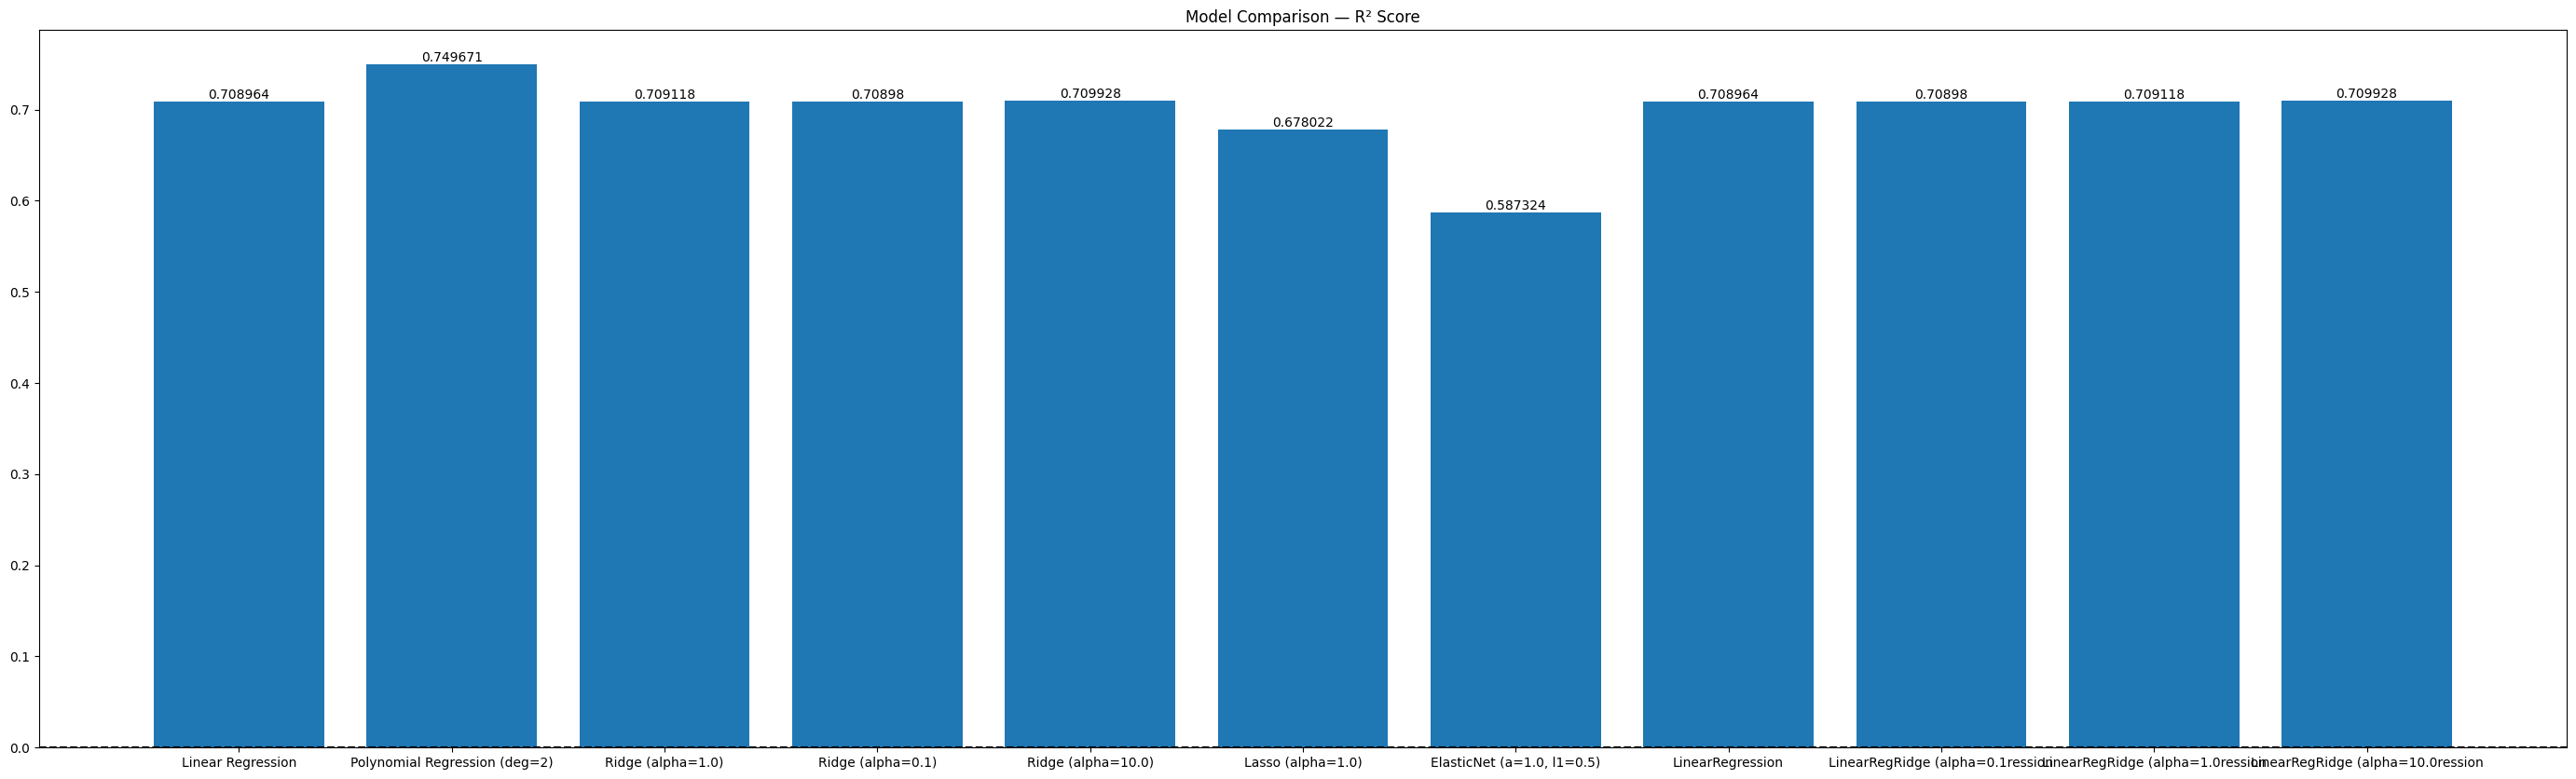

In [ ]:
# TODO: Plot a bar chart comparing the R² scores of all five models
# Models on the x-axis, R² score on the y-axis
# Add a horizontal dashed line at R²=0 as a reference
# Title: 'Model Comparison — R² Score'
# Hint: use the results DataFrame you built above
plt.figure(figsize=(35, 10))
plt.bar(results_df.index, results_df['R2'])
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Model Comparison — R² Score')
plt.bar_label(plt.gca().containers[0])

plt.show()


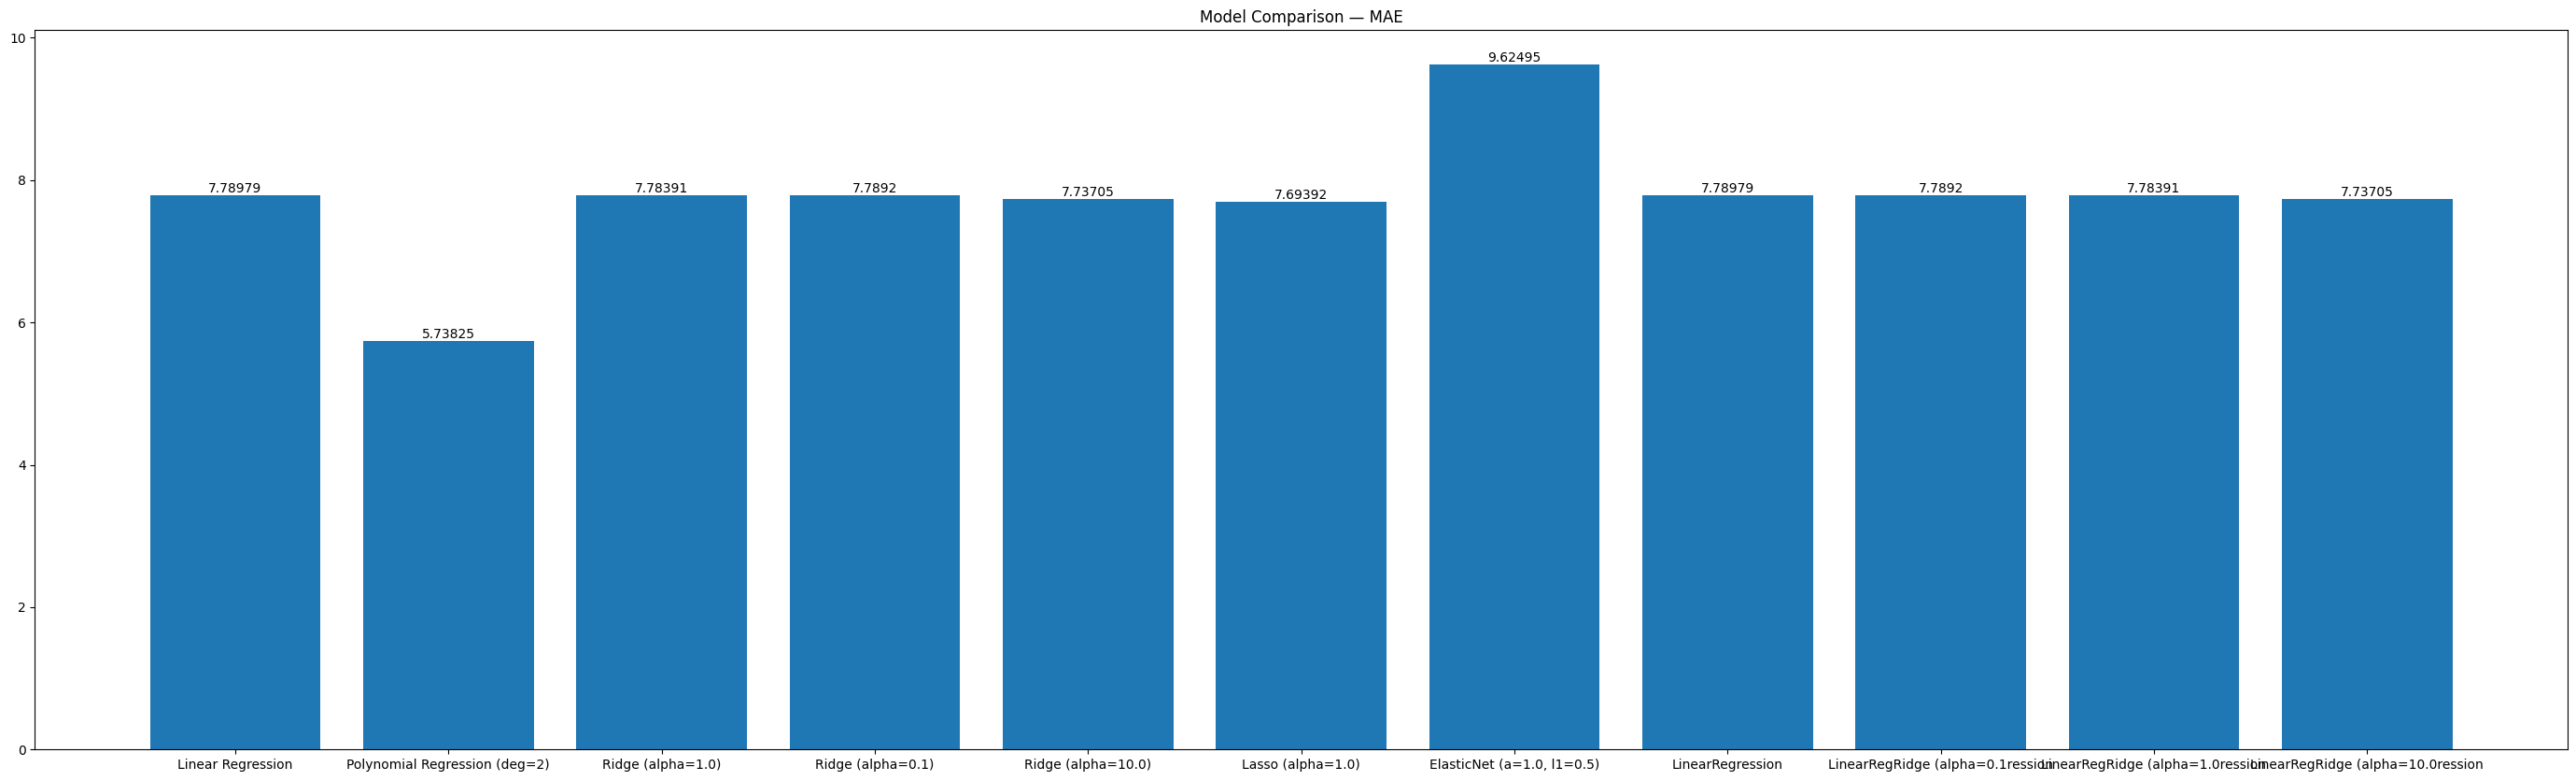

In [ ]:
# TODO: Plot a second bar chart comparing MAE scores of all five models
# Lower MAE = better model
# Title: 'Model Comparison — MAE'

plt.figure(figsize=(35, 10))
plt.bar(results_df.index, results_df['MAE'])
plt.title('Model Comparison — MAE')
plt.bar_label(plt.gca().containers[0])
plt.show()



---
## 12. Residual Analysis — Linear Regression

**What is a residual?**  
A residual is the difference between the actual value and the predicted value:  
`residual = actual - predicted`

**Why do we analyze residuals?**  
A good model should have residuals that:
- Are centered around zero (no systematic bias)
- Are randomly scattered — no pattern
- Are approximately normally distributed

If residuals show a clear pattern, the model is missing something — maybe a non-linear relationship.

**Two plots we use:**

| Plot | What to look for |
|------|-----------------|
| Residuals vs Predicted | Points should be randomly scattered around the zero line |
| Histogram of residuals | Should be approximately bell-shaped and centered at zero |


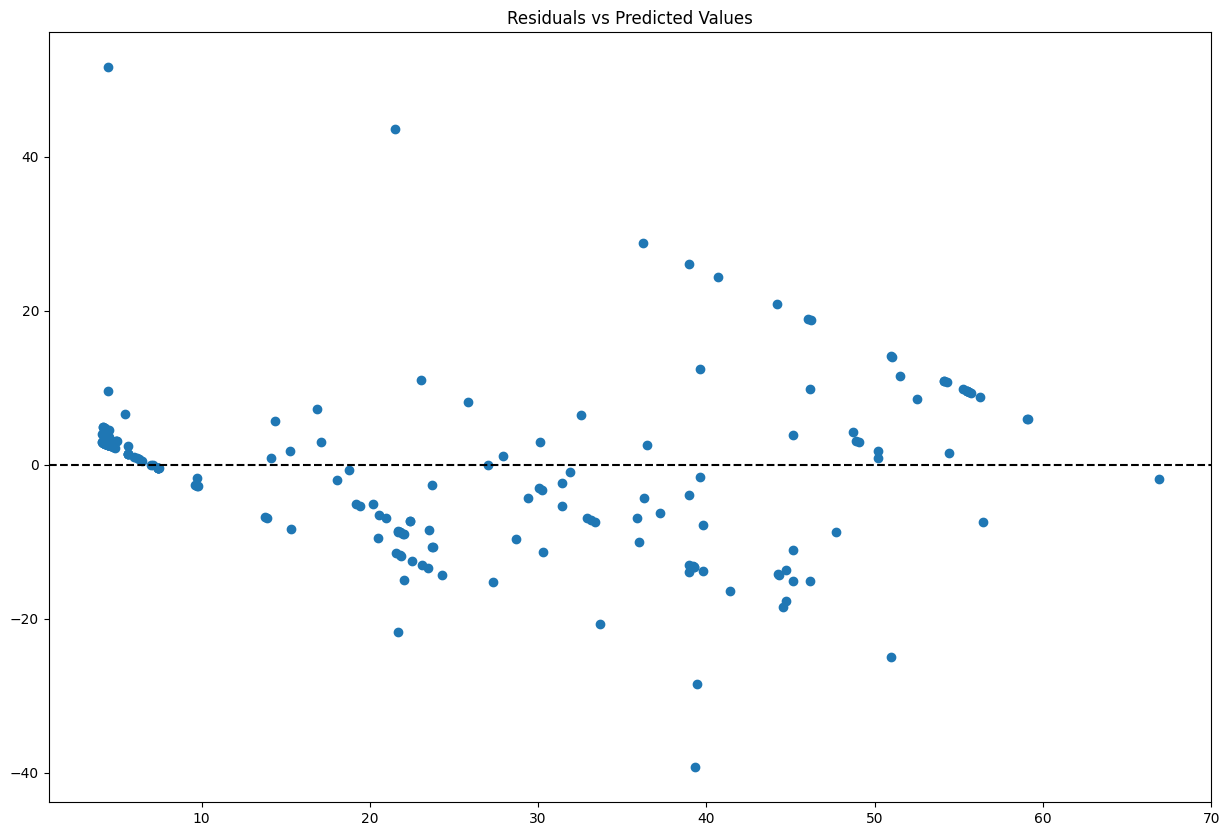

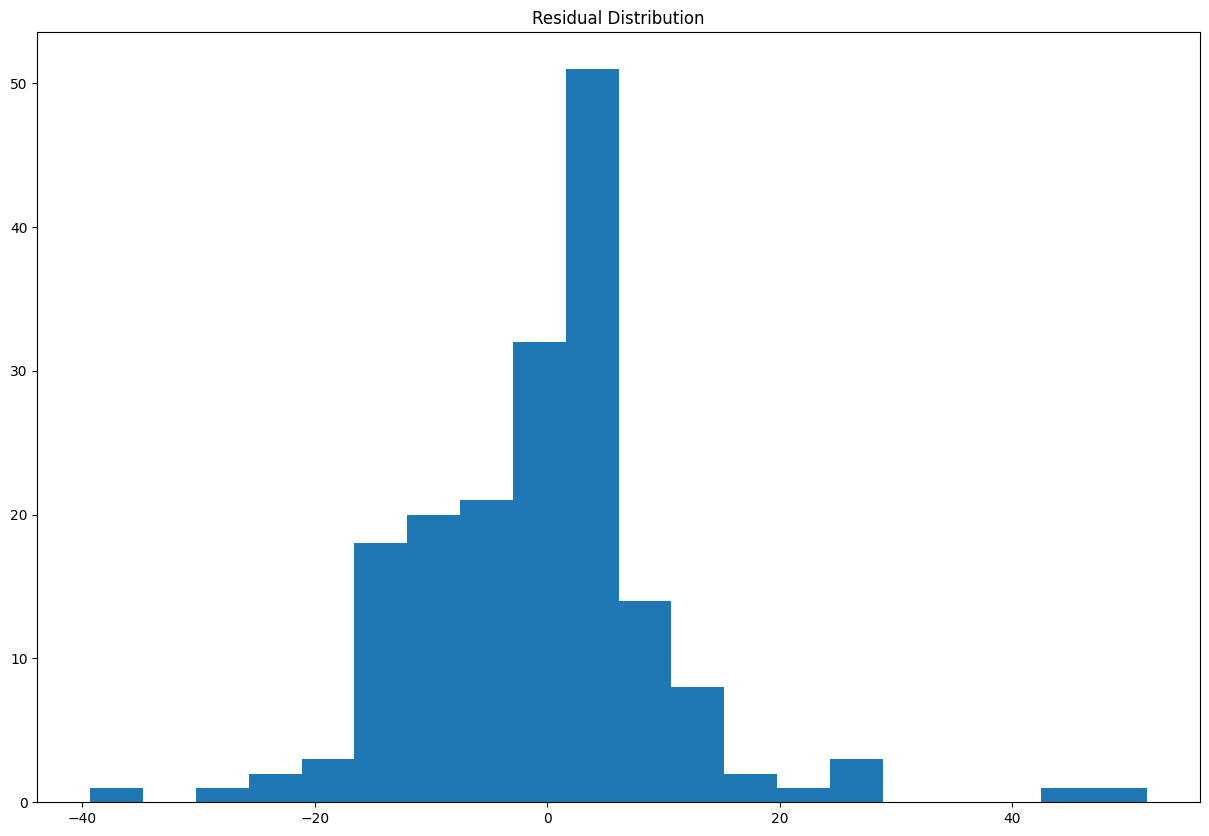

In [ ]:
# TODO: Using the Linear Regression model predictions, calculate residuals
# residuals = y_test - y_pred_linear
# Plot 1: Scatter plot of y_pred (x-axis) vs residuals (y-axis)
#         Add a horizontal line at y=0
#         Title: 'Residuals vs Predicted Values'
# Plot 2: Histogram of residuals
#         Title: 'Residual Distribution'

residuals = y_test - y_pred
plt.figure(figsize=(15, 10))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.show()

plt.figure(figsize=(15, 10))
plt.hist(residuals, bins=20)
plt.title('Residual Distribution')
plt.show()



---
## Session Summary

| Step | What We Did |
|------|------------|
| 1 | Imported all required libraries |
| 2 | Loaded the clean Titanic dataset |
| 3 | Defined features X and target y (Fare) |
| 4 | Split into train and test sets (80/20) |
| 5 | Built an evaluation helper (MAE, MSE, R²) |
| 6 | Trained and evaluated Linear Regression |
| 7 | Trained and evaluated Polynomial Regression (degree=2) |
| 8 | Trained and evaluated Ridge Regression (L2) |
| 9 | Trained and evaluated Lasso Regression (L1) |
| 10 | Trained and evaluated ElasticNet (L1 + L2) |
| 11 | Compared all models in one table and two charts |
| 12 | Analyzed residuals to check model assumptions |

---


---

## Interview Questions — Test Your Understanding

---

**1. What is the difference between a regression problem and a classification problem? Give one example of each.**

-Regression:
It is a form of supervised learning used when the target variable consists of continuous numerical values.
Example: Predicting house prices or car prices.

Classification:
It is also a form of supervised learning, but it is used when the target variable consists of discrete values.
Example: Predicting heart disease (patient has the disease vs. does not have the disease).

---

**2. What does R² = 0.85 actually mean in plain English?**
-Your model is able to explain about 85% of the variation in the real data.

---

**3. Why does MSE punish large errors more than MAE does? Give a numerical example.**
- Because MSE (Mean Squared Error) squares the error, whereas MAE (Mean Absolute Error) takes only the absolute value.
Suppose we have two errors:

Small error = 2
Large error = 10

✅ MAE:

We take only the absolute values:

|2| = 2
|10| = 10

👉 The average (of the two):

MAE = (2 + 10) / 2 = 6

❌ MSE:

We square the errors:

2² = 4
10² = 100

👉 The average:

MSE = (4 + 100) / 2 = 52
---

**4. What is regularization, and why do we add a penalty term to the loss function?**
-Regularization is a machine learning technique used to mitigate the problem known as overfitting.
- Why do we add the penalty?

Because we want the model to:

Avoid excessively large weights
Remain simple and more "general"
Perform better on new data

---

**5. What is the main practical difference between Ridge and Lasso? Which one performs feature selection, and how?**

- Ridge Regression (L2 Regularization)
Adds a penalty:
λ∑w²
- Result:
Reduces large weights
But does not set them to zero

👉 This means all features remain, but with smaller weights.


-Lasso Regression (L1 Regularization)
Adds a penalty:
λ∑|w|
- Result:
Reduces weights
And some weights become exactly zero

👉 Meaning it effectively eliminates some features
---

**6. If Lasso sets a coefficient to zero, what does that mean about that feature?**

-This feature has been completely disregarded in the model; this means it does not affect the prediction, effectively as if it had been removed from the data.

---

**7. You train a model and get R² = 0.95 on the training set but R² = 0.40 on the test set. What is happening, and how would you fix it?**

- The Problem: Overfitting

The Model:

It essentially memorizes the training data instead of learning general patterns.
Consequently, its performance collapses on the test set.

- How do we solve this?
Use regularization.
Ridge or Lasso.
This reduces model complexity and prevents overfitting.

---

**8. When would you choose ElasticNet over pure Ridge or pure Lasso?**
-Use ElasticNet when:

You have data with many correlated features and want to strike a balance between reducing complexity and selecting features in a stable manner.
---

**9. What is the difference between `PolynomialFeatures.fit_transform()` and `.transform()`? Why do we use each on different sets?**

-fit_transform(): Learns the transformation and applies it → Used on training data.
-transform(): Applies the same transformation without learning → Used on test or new data.

👉 Reason: To prevent data leakage and ensure a fair test.

---

**10. What do residuals tell you about a model? If you plot residuals vs predicted values and see a clear curve pattern, what does that suggest?**
- What was the model's error for each prediction?
-A plot of residuals versus predicted values ​​shows a curved shape (U-shape or inverted U-shape).

- This indicates:

The model is not correctly capturing the relationship; there is a pattern in the data that the model is failing to account for. To resolve this issue, a more powerful model should be used.

---

> **Tip:** Try answering from memory first, then scroll back through the notebook to check.  
> If you can explain *why* — not just *what* — you understood the lesson.

---
*DOT PY · Data Science & AI Program · Module 02 · 2026*
